In [1]:
# Instalação das bibliotecas necessárias
!pip install tweepy pandas networkx matplotlib python-louvain cdlib scipy numpy seaborn

In [2]:
# Importação das bibliotecas
import tweepy
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import community as community_louvain
from cdlib import algorithms, evaluation
import os
import json
from datetime import datetime
import re

Note: to be able to use all crisp methods, you need to install some additional packages:  {'bayanpy', 'infomap', 'graph_tool', 'wurlitzer'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer'}


In [3]:
# Configuração das credenciais da API do Twitter
# Substitua com suas próprias credenciais
consumer_key = "****************************"
consumer_secret = "****************************"
access_token = "****************************"
access_token_secret = "****************************"
bearer_token = "****************************"

# Autenticação com a API v2 do Twitter
client = tweepy.Client(
    bearer_token=bearer_token,
    consumer_key=consumer_key,
    consumer_secret=consumer_secret,
    access_token=access_token,
    access_token_secret=access_token_secret
)

print("Autenticação realizada com sucesso!")

Autenticação realizada com sucesso!


In [4]:
import time

query = '(ENEM OR "prova do ENEM" OR "enem 2025" OR "enem2025") lang:pt -is:retweet'

tweet_fields = ['author_id', 'created_at', 'public_metrics', 'referenced_tweets', 'entities', 'lang']
user_fields = ['username', 'name', 'description', 'public_metrics']
expansions = ['author_id', 'referenced_tweets.id', 'referenced_tweets.id.author_id', 'entities.mentions.username']

tweets = []
users = {}

def collect_tweets(query, max_results=500):
    collected = 0
    next_token = None
    retry_count = 0
    
    while collected < max_results:
        results_per_page = min(100, max_results - collected)
        
        try:
            response = client.search_recent_tweets(
                query=query,
                tweet_fields=tweet_fields,
                user_fields=user_fields,
                expansions=expansions,
                max_results=results_per_page,
                next_token=next_token
            )
            
            if not response.data:
                print("Nenhum tweet novo encontrado.")
                break
            
            tweets.extend(response.data)
            
            if response.includes and 'users' in response.includes:
                users.update({user.id: user for user in response.includes['users']})
            
            collected += len(response.data)
            print(f"{collected}/{max_results} tweets | Último ID: {response.data[-1].id}")
            
            next_token = response.meta.get('next_token')
            if not next_token:
                print("Nenhuma próxima página disponível.")
                break
            
            # pausa entre as páginas para evitar rate limit
            time.sleep(5)
        
        except tweepy.TooManyRequests:
            wait_time = 15 * 60  # 15 minutos
            print(f"Limite atingido. Aguardando {wait_time/60} minutos...")
            time.sleep(wait_time)
            retry_count += 1
            if retry_count >= 3:
                break
        
        except Exception as e:
            print(f"Erro: {type(e).__name__} - {e}")
            retry_count += 1
            time.sleep(10)
            if retry_count >= 3:
                break

    return collected

total_collected = collect_tweets(query)
print(f"Total de tweets coletados: {total_collected}")


100/500 tweets | Último ID: 1978226723033317641
Limite atingido. Aguardando 15.0 minutos...
199/500 tweets | Último ID: 1978212165954772993
Limite atingido. Aguardando 15.0 minutos...
Limite atingido. Aguardando 15.0 minutos...
Total de tweets coletados: 199


In [5]:
# Criar DataFrame com os tweets
tweets_data = []

for tweet in tweets:
    # Dados básicos do tweet
    tweet_data = {
        'tweet_id': tweet.id,
        'author_id': tweet.author_id,
        'author_username': users[tweet.author_id].username if tweet.author_id in users else None,
        'text': tweet.text,
        'created_at': tweet.created_at,
        'retweet_count': tweet.public_metrics['retweet_count'] if hasattr(tweet, 'public_metrics') else 0,
        'reply_count': tweet.public_metrics['reply_count'] if hasattr(tweet, 'public_metrics') else 0,
        'like_count': tweet.public_metrics['like_count'] if hasattr(tweet, 'public_metrics') else 0,
        'quote_count': tweet.public_metrics['quote_count'] if hasattr(tweet, 'public_metrics') else 0,
        'referenced_tweet_id': None,
        'reference_type': None,
        'mentions': []
    }
    
    # Verificar se é uma resposta, retweet ou citação
    if hasattr(tweet, 'referenced_tweets') and tweet.referenced_tweets:
        tweet_data['referenced_tweet_id'] = tweet.referenced_tweets[0].id
        tweet_data['reference_type'] = tweet.referenced_tweets[0].type
    
    # Extrair menções
    if hasattr(tweet, 'entities') and tweet.entities and 'mentions' in tweet.entities:
        for mention in tweet.entities['mentions']:
            tweet_data['mentions'].append(mention['username'])
    
    tweets_data.append(tweet_data)

# Criar DataFrame
df_tweets = pd.DataFrame(tweets_data)

# Exibir as primeiras linhas
print(f"Total de tweets processados: {len(df_tweets)}")
df_tweets.head()

Total de tweets processados: 199


,tweet_id,author_id,author_username,text,created_at,retweet_count,reply_count,like_count,quote_count,referenced_tweet_id,reference_type,mentions
0,1978239334173048971,1968777698601267200,simusas2025,GABARITO SAS ENEM 6 SIMULADO SAS ENEM \nAINDA ...,2025-10-14 23:19:45+00:00,1,0,0,0,NaN,None,[]
1,1978239218481602878,1520880582338699265,deiaferracin,"@toninhodocall Falando nisso, é as taxas como ...",2025-10-14 23:19:18+00:00,0,0,0,0,1.978173e+18,replied_to,[toninhodocall]
2,1978239121614164115,1298635595389050881,aliwpig,será que a redação do enem tem como ser sobre ...,2025-10-14 23:18:55+00:00,0,0,0,0,NaN,None,[]
3,1978238961647514035,1935334672323489792,Houpebunny,@Anotherwayy5 Eu faço toda etapa um simulado m...,2025-10-14 23:18:17+00:00,0,0,0,0,1.978234e+18,replied_to,[Anotherwayy5]
4,1978238788708045131,1789332217883213824,anyraroki,o aulão pré enem cai no mesmo dia q a festa de...,2025-10-14 23:17:35+00:00,0,0,0,0,NaN,None,[]


In [6]:
# Criar grafo direcionado para rede de menções
G_mentions = nx.DiGraph()

# Adicionar arestas para cada menção
for _, tweet in df_tweets.iterrows():
    author = tweet['author_username']
    
    # Adicionar nó do autor
    if not G_mentions.has_node(author):
        G_mentions.add_node(author, type='user')
    
    # Adicionar arestas para cada menção
    for mention in tweet['mentions']:
        if not G_mentions.has_node(mention):
            G_mentions.add_node(mention, type='user')
        
        # Adicionar ou incrementar peso da aresta
        if G_mentions.has_edge(author, mention):
            G_mentions[author][mention]['weight'] += 1
        else:
            G_mentions.add_edge(author, mention, weight=1)

# Informações básicas da rede
print(f"Rede de Menções:")
print(f"Número de nós: {G_mentions.number_of_nodes()}")
print(f"Número de arestas: {G_mentions.number_of_edges()}")
print(f"Densidade da rede: {nx.density(G_mentions):.6f}")

Rede de Menções:
Número de nós: 240
Número de arestas: 55
Densidade da rede: 0.000959


In [7]:
# Criar grafo direcionado para rede de respostas e retweets
G_interactions = nx.DiGraph()

# Mapear IDs de tweets para autores
tweet_to_author = {}
for _, tweet in df_tweets.iterrows():
    tweet_to_author[tweet['tweet_id']] = tweet['author_username']

# Adicionar arestas para respostas e retweets
for _, tweet in df_tweets.iterrows():
    author = tweet['author_username']
    
    # Adicionar nó do autor
    if not G_interactions.has_node(author):
        G_interactions.add_node(author, type='user')
    
    # Se for resposta ou retweet, adicionar aresta
    if tweet['referenced_tweet_id'] is not None:
        # Encontrar o autor do tweet referenciado
        referenced_author = None
        for _, ref_tweet in df_tweets.iterrows():
            if ref_tweet['tweet_id'] == tweet['referenced_tweet_id']:
                referenced_author = ref_tweet['author_username']
                break
        
        if referenced_author and referenced_author != author:
            if not G_interactions.has_node(referenced_author):
                G_interactions.add_node(referenced_author, type='user')
            
            # Adicionar ou incrementar peso da aresta
            if G_interactions.has_edge(author, referenced_author):
                G_interactions[author][referenced_author]['weight'] += 1
            else:
                G_interactions.add_edge(author, referenced_author, weight=1)

# Informações básicas da rede
print(f"Rede de Interações (Respostas e Retweets):")
print(f"Número de nós: {G_interactions.number_of_nodes()}")
print(f"Número de arestas: {G_interactions.number_of_edges()}")
print(f"Densidade da rede: {nx.density(G_interactions):.6f}")

Rede de Interações (Respostas e Retweets):
Número de nós: 190
Número de arestas: 0
Densidade da rede: 0.000000


In [8]:
# Criar grafo direcionado para rede combinada
G_combined = nx.DiGraph()

# Adicionar todas as arestas da rede de menções
for u, v, data in G_mentions.edges(data=True):
    if not G_combined.has_node(u):
        G_combined.add_node(u, type='user')
    if not G_combined.has_node(v):
        G_combined.add_node(v, type='user')
    
    G_combined.add_edge(u, v, weight=data['weight'], type='mention')

# Adicionar todas as arestas da rede de interações
for u, v, data in G_interactions.edges(data=True):
    if not G_combined.has_node(u):
        G_combined.add_node(u, type='user')
    if not G_combined.has_node(v):
        G_combined.add_node(v, type='user')
    
    if G_combined.has_edge(u, v):
        # Se já existe uma aresta, somar os pesos
        G_combined[u][v]['weight'] += data['weight']
        G_combined[u][v]['type'] = 'multiple'
    else:
        G_combined.add_edge(u, v, weight=data['weight'], type='interaction')

# Informações básicas da rede
print(f"Rede Combinada:")
print(f"Número de nós: {G_combined.number_of_nodes()}")
print(f"Número de arestas: {G_combined.number_of_edges()}")
print(f"Densidade da rede: {nx.density(G_combined):.6f}")

Rede Combinada:
Número de nós: 99
Número de arestas: 55
Densidade da rede: 0.005669


In [9]:
# Criar diretório para salvar as visualizações
os.makedirs('visualizacoes', exist_ok=True)

# Função para visualizar rede
def visualize_network_jupyter(G, title, filename, layout=None, show=True):
    plt.figure(figsize=(12, 12))
    
    # Definir layout
    if layout is None:
        pos = nx.spring_layout(G, seed=42)
    else:
        pos = layout
    
    # Obter pesos das arestas e graus dos nós
    edge_weights = [G[u][v]['weight'] * 0.5 for u, v in G.edges()]
    node_sizes = [30 + 10 * G.degree(node) for node in G.nodes()]
    
    # Desenhar a rede
    nx.draw_networkx(
        G,
        pos=pos,
        with_labels=False,
        node_size=node_sizes,
        node_color='lightblue',
        edge_color='gray',
        width=edge_weights,
        alpha=0.7
    )
    
    # Adicionar rótulos para os nós mais importantes
    top_nodes = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:10]
    labels = {node: node for node, _ in top_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight='bold')
    
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    
    # Salvar a imagem
    os.makedirs('visualizacoes', exist_ok=True)
    plt.savefig(f'visualizacoes/{filename}.png', dpi=300, bbox_inches='tight')
    
    # Mostrar no notebook se show=True
    if show:
        plt.show()
    else:
        plt.close()
    
    return pos



--- Rede de Menções ---


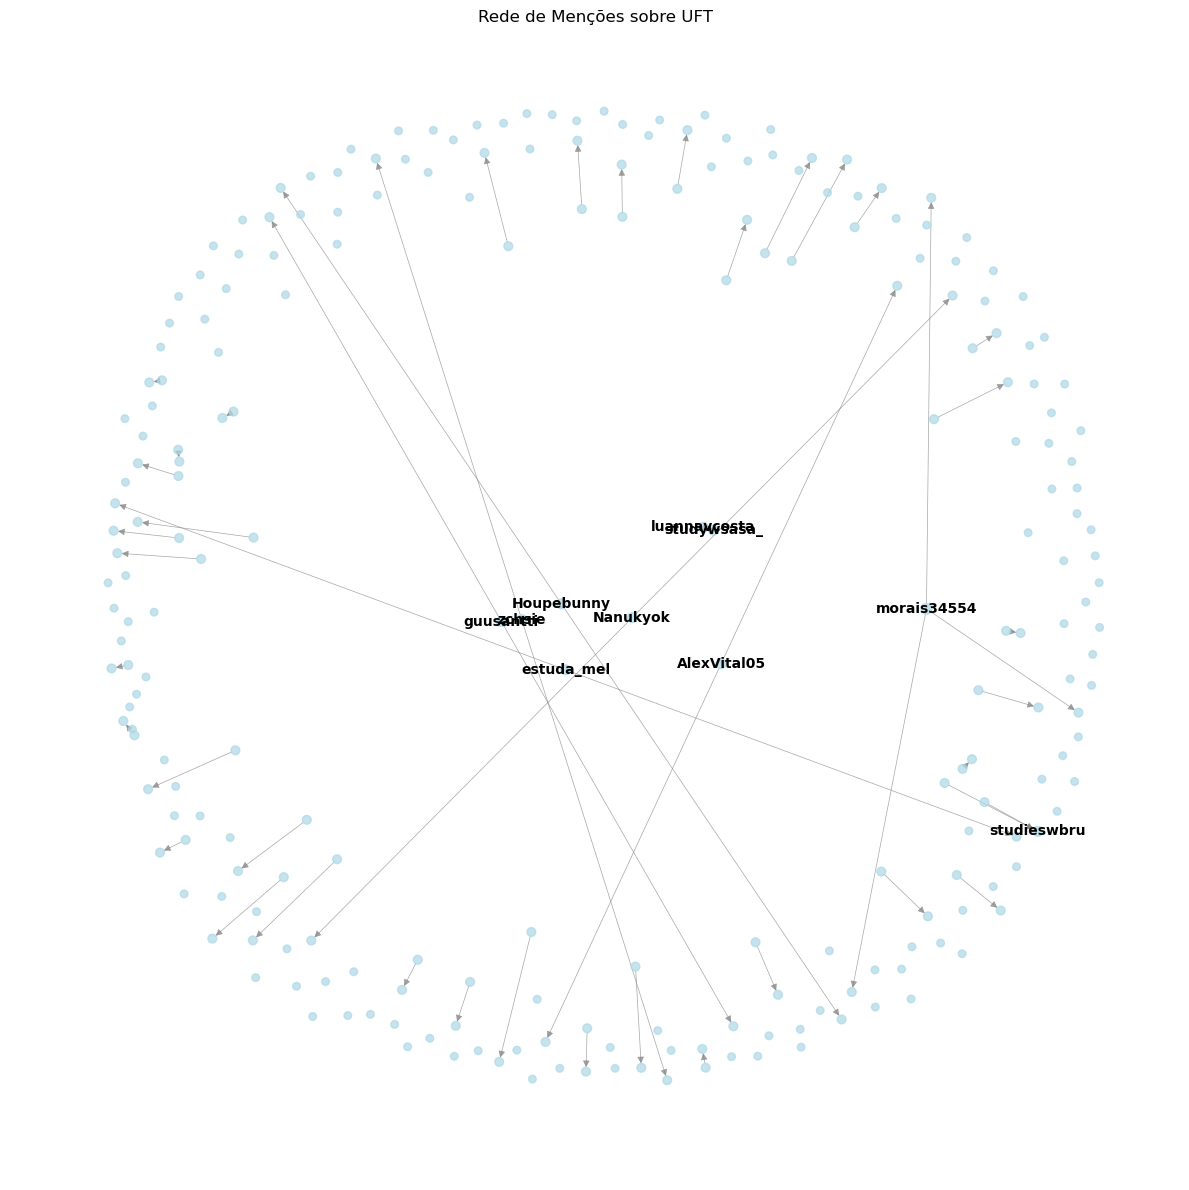

In [10]:
print("\n--- Rede de Menções ---")
pos_mentions = visualize_network_jupyter(G_mentions, "Rede de Menções sobre ENEM", "rede_mencoes")


--- Rede de Interações ---


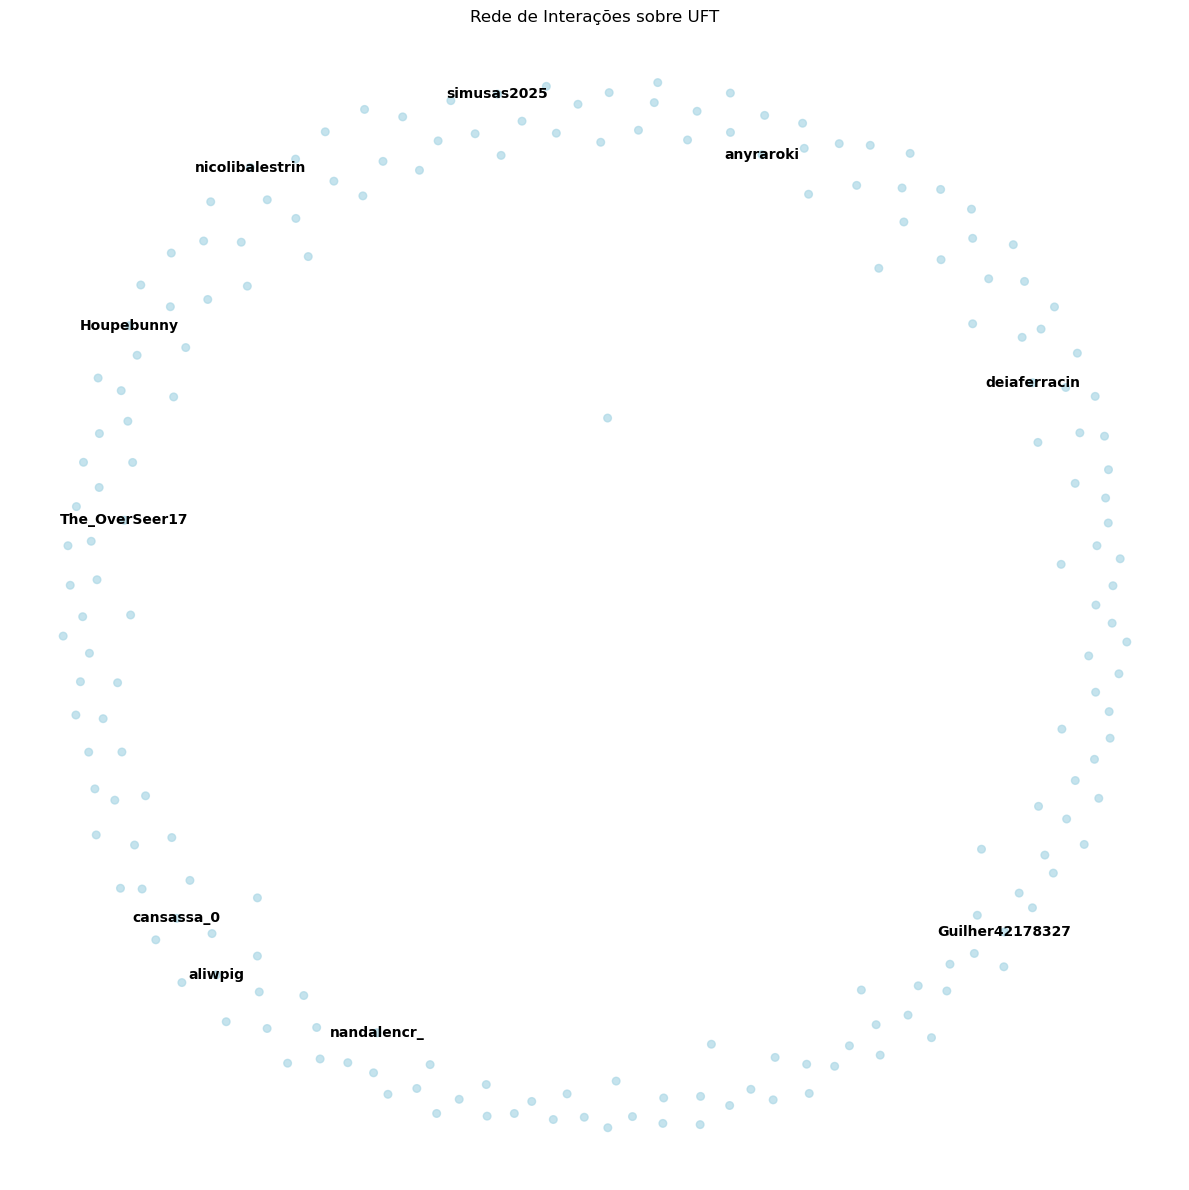

In [11]:
print("\n--- Rede de Interações ---")
pos_interactions = visualize_network_jupyter(G_interactions, "Rede de Interações sobre ENEM", "rede_interacoes")


--- Rede Combinada ---


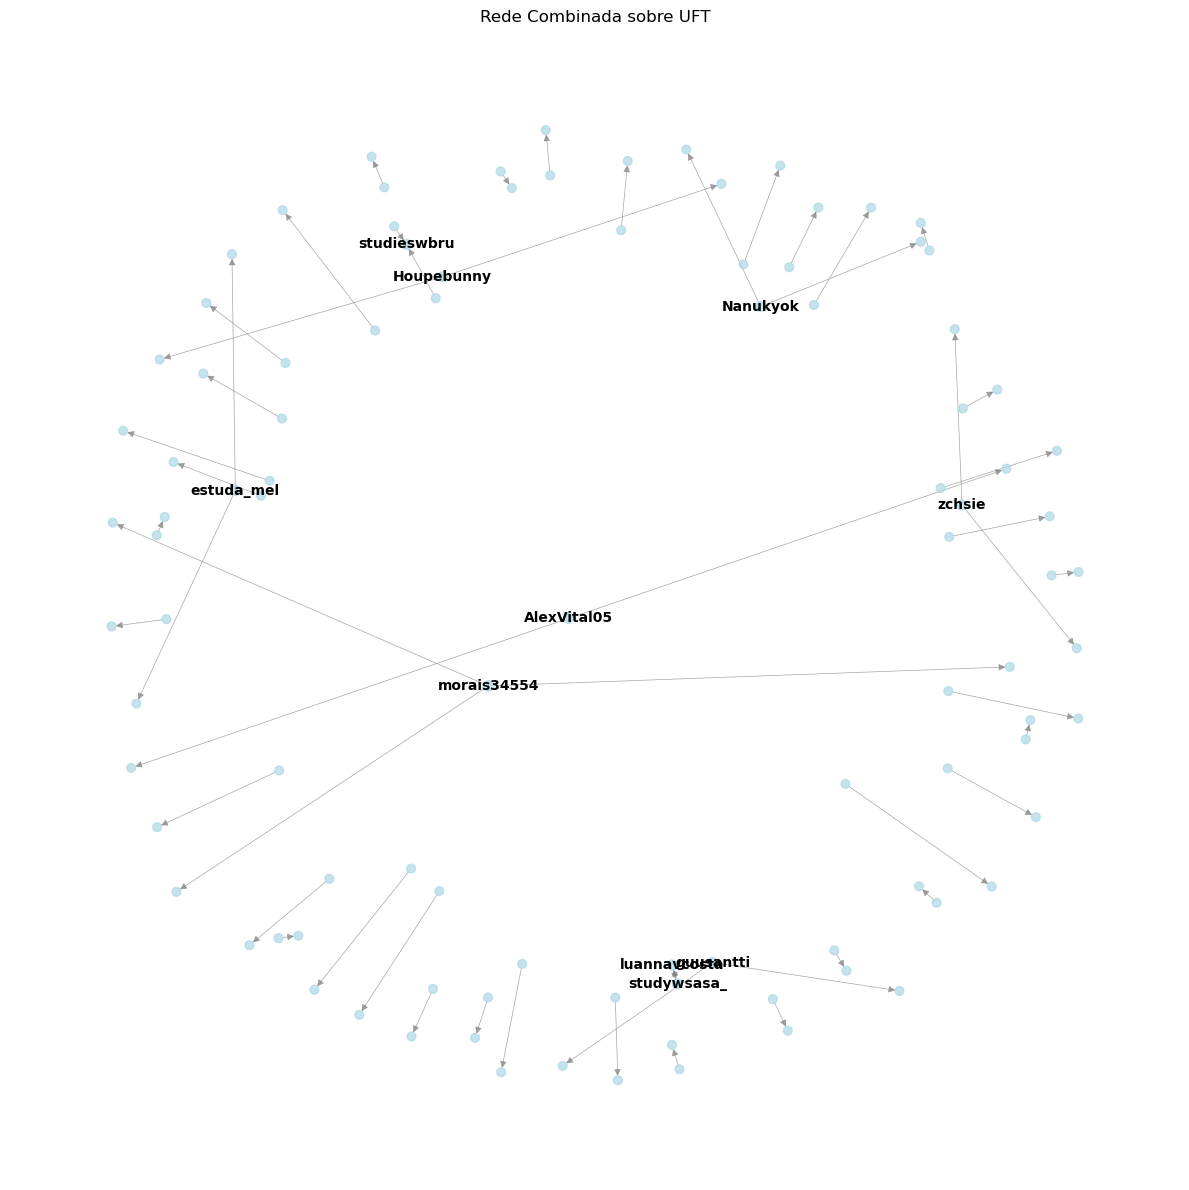

In [12]:
print("\n--- Rede Combinada ---")
pos_combined = visualize_network_jupyter(G_combined, "Rede Combinada sobre ENEM", "rede_combinada")

In [13]:
# Converter para grafo não-direcionado para detecção de comunidades
G_undirected = G_combined.to_undirected()

# Criar diretório para resultados
os.makedirs('resultados_comunidades', exist_ok=True)


--- Aplicando Algoritmo de Louvain ---
Número de comunidades detectadas: 45
Tamanho médio das comunidades: 2.20 nós
Maior comunidade: 4 nós
Menor comunidade: 2 nós
Modularidade: 0.9746


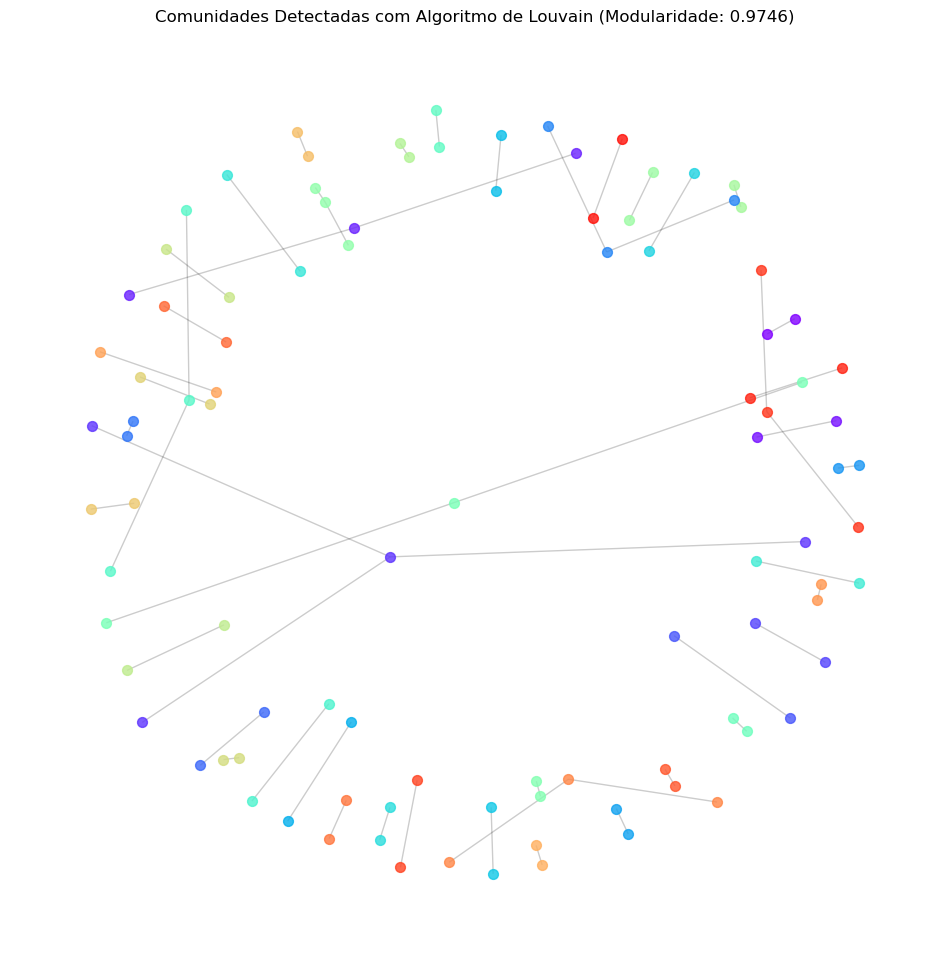

In [14]:
# Aplicar algoritmo de Louvain
print("\n--- Aplicando Algoritmo de Louvain ---")
partition = community_louvain.best_partition(G_undirected)

# Converter para formato de lista de comunidades
communities = {}
for node, community_id in partition.items():
    if community_id not in communities:
        communities[community_id] = []
    communities[community_id].append(node)

# Estatísticas das comunidades
community_sizes = [len(nodes) for nodes in communities.values()]

print(f"Número de comunidades detectadas: {len(communities)}")
print(f"Tamanho médio das comunidades: {np.mean(community_sizes):.2f} nós")
print(f"Maior comunidade: {max(community_sizes)} nós")
print(f"Menor comunidade: {min(community_sizes)} nós")

# Calcular modularidade
modularity = community_louvain.modularity(partition, G_undirected)
print(f"Modularidade: {modularity:.4f}")

# Visualizar comunidades
plt.figure(figsize=(12, 12))
cmap = plt.cm.rainbow

# Desenhar nós coloridos por comunidade
for community_id, nodes in communities.items():
    nx.draw_networkx_nodes(G_undirected, pos_combined, 
                          nodelist=nodes, 
                          node_color=[cmap(community_id / len(communities))], 
                          node_size=50, 
                          alpha=0.8)

# Desenhar arestas
nx.draw_networkx_edges(G_undirected, pos_combined, alpha=0.2)

plt.title(f"Comunidades Detectadas com Algoritmo de Louvain (Modularidade: {modularity:.4f})")
plt.axis('off')
plt.savefig("resultados_comunidades/louvain_comunidades.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


--- Aplicando Algoritmo Label Propagation ---
Número de comunidades detectadas: 45
Tamanho médio das comunidades: 2.20 nós
Maior comunidade: 4 nós
Menor comunidade: 2 nós
Modularidade: 0.9746


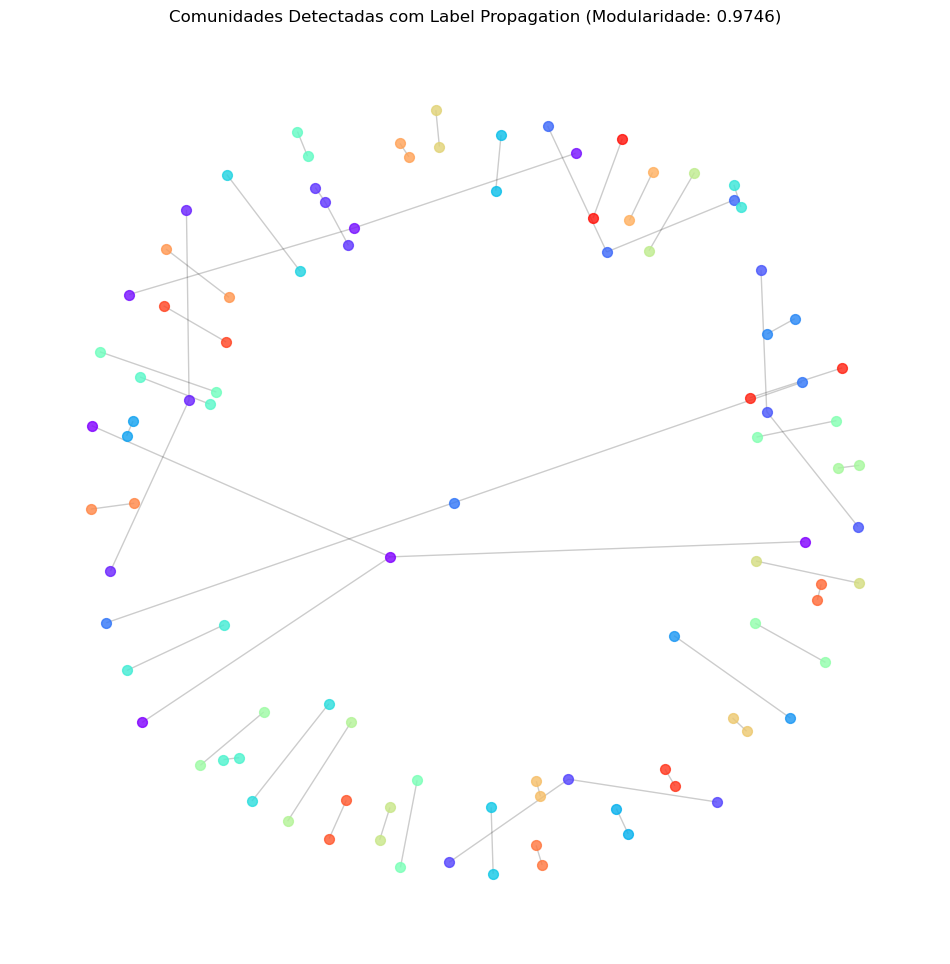

In [15]:
# Aplicar Label Propagation usando cdlib
print("\n--- Aplicando Algoritmo Label Propagation ---")
lp_result = algorithms.label_propagation(G_undirected)

# Extrair comunidades
lp_communities = lp_result.communities

# Estatísticas das comunidades
lp_sizes = [len(community) for community in lp_communities]

print(f"Número de comunidades detectadas: {len(lp_communities)}")
print(f"Tamanho médio das comunidades: {np.mean(lp_sizes):.2f} nós")
print(f"Maior comunidade: {max(lp_sizes)} nós")
print(f"Menor comunidade: {min(lp_sizes)} nós")

# Calcular modularidade
lp_modularity = evaluation.newman_girvan_modularity(G_undirected, lp_result).score
print(f"Modularidade: {lp_modularity:.4f}")

# Visualizar comunidades Label Propagation
plt.figure(figsize=(12, 12))

# Desenhar nós coloridos por comunidade
for i, community in enumerate(lp_communities):
    nx.draw_networkx_nodes(G_undirected, pos_combined, 
                          nodelist=community, 
                          node_color=[cmap(i / len(lp_communities))], 
                          node_size=50, 
                          alpha=0.8)

# Desenhar arestas
nx.draw_networkx_edges(G_undirected, pos_combined, alpha=0.2)

plt.title(f"Comunidades Detectadas com Label Propagation (Modularidade: {lp_modularity:.4f})")
plt.axis('off')
plt.savefig("resultados_comunidades/label_propagation_comunidades.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


--- Aplicando Algoritmo Leiden ---
Número de comunidades detectadas: 45
Tamanho médio das comunidades: 2.20 nós
Maior comunidade: 4 nós
Menor comunidade: 2 nós
Modularidade: 0.9746


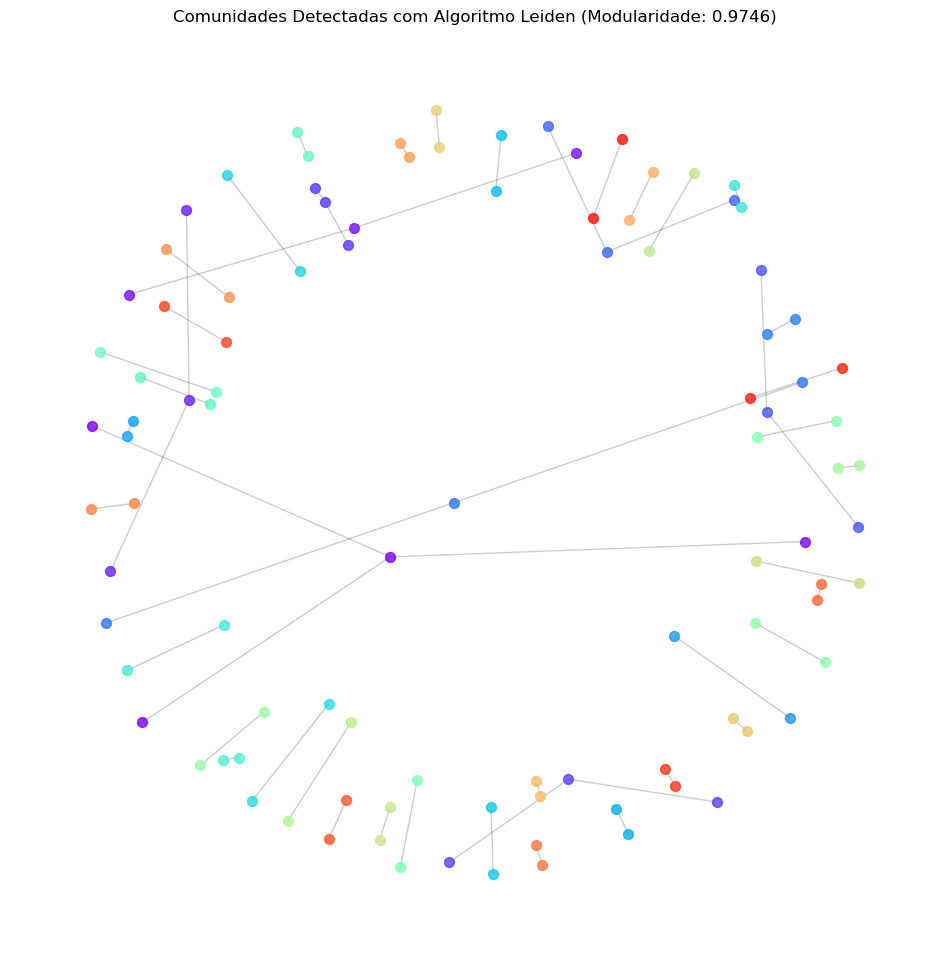

In [16]:
# Aplicar Leiden usando cdlib
print("\n--- Aplicando Algoritmo Leiden ---")
leiden_result = algorithms.leiden(G_undirected)

# Extrair comunidades
leiden_communities = leiden_result.communities

# Estatísticas das comunidades
leiden_sizes = [len(community) for community in leiden_communities]

print(f"Número de comunidades detectadas: {len(leiden_communities)}")
print(f"Tamanho médio das comunidades: {np.mean(leiden_sizes):.2f} nós")
print(f"Maior comunidade: {max(leiden_sizes)} nós")
print(f"Menor comunidade: {min(leiden_sizes)} nós")

# Calcular modularidade
leiden_modularity = evaluation.newman_girvan_modularity(G_undirected, leiden_result).score
print(f"Modularidade: {leiden_modularity:.4f}")

# Visualizar comunidades Leiden
plt.figure(figsize=(12, 12))

# Desenhar nós coloridos por comunidade
for i, community in enumerate(leiden_communities):
    nx.draw_networkx_nodes(G_undirected, pos_combined, 
                          nodelist=community, 
                          node_color=[cmap(i / len(leiden_communities))], 
                          node_size=50, 
                          alpha=0.8)

# Desenhar arestas
nx.draw_networkx_edges(G_undirected, pos_combined, alpha=0.2)

plt.title(f"Comunidades Detectadas com Algoritmo Leiden (Modularidade: {leiden_modularity:.4f})")
plt.axis('off')
plt.savefig("resultados_comunidades/leiden_comunidades.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


--- Comparação dos Algoritmos ---
           Algoritmo  Número de Comunidades  Modularidade  Maior Comunidade  \
0            Louvain                     45      0.974623                 4   
1  Label Propagation                     45      0.974623                 4   
2             Leiden                     45      0.974623                 4   

   Menor Comunidade  Tamanho Médio  
0                 2            2.2  
1                 2            2.2  
2                 2            2.2  


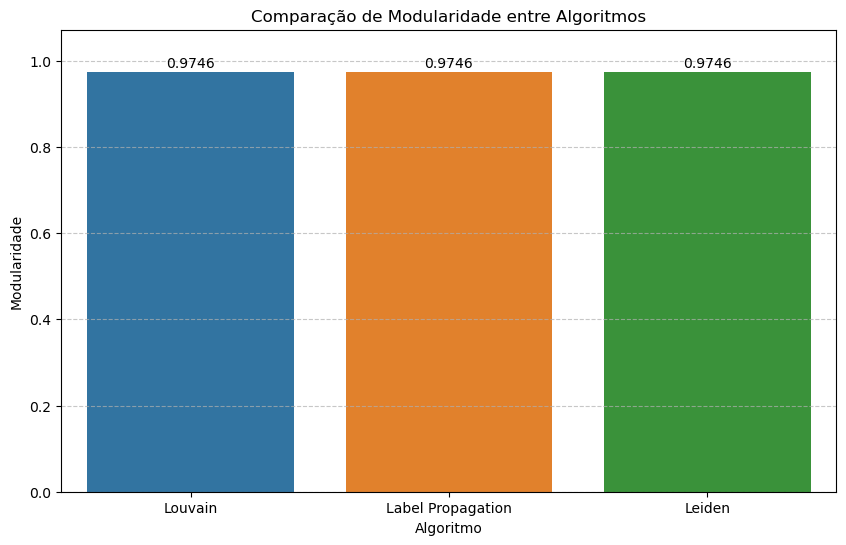

In [17]:
# Criar DataFrame de comparação
comparison_df = pd.DataFrame({
    'Algoritmo': ['Louvain', 'Label Propagation', 'Leiden'],
    'Número de Comunidades': [len(communities), len(lp_communities), len(leiden_communities)],
    'Modularidade': [modularity, lp_modularity, leiden_modularity],
    'Maior Comunidade': [max(community_sizes), max(lp_sizes), max(leiden_sizes)],
    'Menor Comunidade': [min(community_sizes), min(lp_sizes), min(leiden_sizes)],
    'Tamanho Médio': [np.mean(community_sizes), np.mean(lp_sizes), np.mean(leiden_sizes)]
})

print("\n--- Comparação dos Algoritmos ---")
print(comparison_df)

# Salvar comparação em CSV
comparison_df.to_csv("resultados_comunidades/algoritmos_comparacao.csv", index=False)

# Visualizar comparação de modularidade
plt.figure(figsize=(10, 6))
sns.barplot(x='Algoritmo', y='Modularidade', data=comparison_df)
plt.title('Comparação de Modularidade entre Algoritmos')
plt.ylim(0, max(comparison_df['Modularidade']) * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(comparison_df['Modularidade']):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.savefig("resultados_comunidades/modularidade_comparacao.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


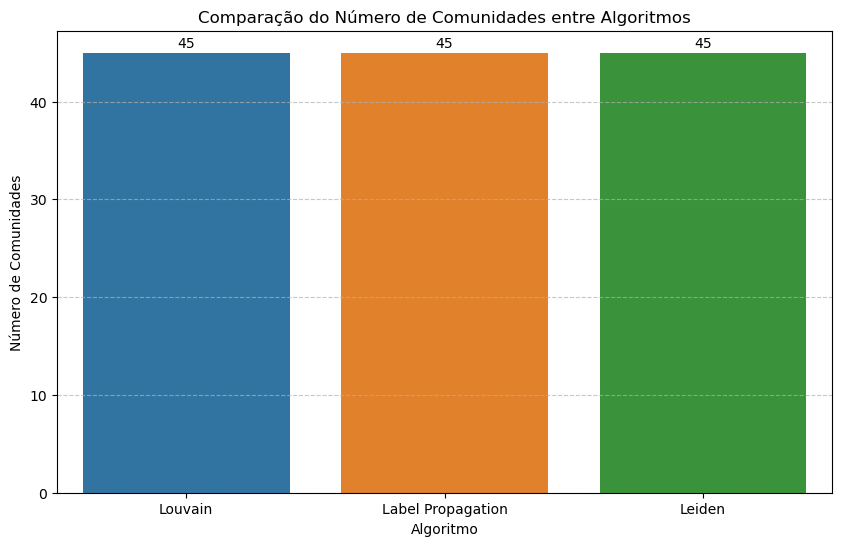

In [18]:
# Visualizar comparação do número de comunidades
plt.figure(figsize=(10, 6))
sns.barplot(x='Algoritmo', y='Número de Comunidades', data=comparison_df)
plt.title('Comparação do Número de Comunidades entre Algoritmos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(comparison_df['Número de Comunidades']):
    plt.text(i, v + 0.5, str(v), ha='center')
plt.savefig("resultados_comunidades/comunidades_comparacao.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [19]:
# Função para analisar as principais comunidades
def analyze_top_communities(communities_dict, G, algorithm_name, top_n=3):
    print(f"\n--- Análise das Principais Comunidades ({algorithm_name}) ---")
    
    # Ordenar comunidades por tamanho
    if isinstance(communities_dict, dict):
        sorted_communities = sorted(communities_dict.items(), key=lambda x: len(x[1]), reverse=True)
        top_communities = sorted_communities[:top_n]
        
        for i, (comm_id, nodes) in enumerate(top_communities):
            print(f"\nComunidade {i+1} (ID: {comm_id}):")
            print(f"  Tamanho: {len(nodes)} nós")
            
            # Identificar nós centrais por grau
            subgraph = G.subgraph(nodes).copy()
            degrees = dict(subgraph.degree())
            top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:5]
            
            print(f"  Nós centrais: {', '.join(top_nodes)}")
            
            # Calcular métricas da comunidade
            density = nx.density(subgraph)
            if len(nodes) > 1:
                clustering = nx.average_clustering(subgraph)
            else:
                clustering = 0
                
            print(f"  Densidade: {density:.4f}")
            print(f"  Coeficiente de Agrupamento: {clustering:.4f}")
            
            # Visualizar a comunidade
            plt.figure(figsize=(8, 8))
            nx.draw(subgraph, 
                    node_size=100,
                    node_color='lightgreen',
                    edge_color='gray',
                    alpha=0.8,
                    with_labels=len(nodes) < 30)
            
            plt.title(f"{algorithm_name} - Comunidade {i+1} (Tamanho: {len(nodes)})")
            plt.savefig(f"resultados_comunidades/{algorithm_name.lower()}_comunidade_{i+1}.png", 
                       dpi=300, bbox_inches='tight')
            plt.close()
    else:
        # Para o caso de lista de comunidades (Label Propagation e Leiden)
        sorted_communities = sorted(communities_dict, key=len, reverse=True)
        top_communities = sorted_communities[:top_n]
        
        for i, nodes in enumerate(top_communities):
            print(f"\nComunidade {i+1}:")
            print(f"  Tamanho: {len(nodes)} nós")
            
            # Identificar nós centrais por grau
            subgraph = G.subgraph(nodes).copy()
            degrees = dict(subgraph.degree())
            top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:5]
            
            print(f"  Nós centrais: {', '.join(top_nodes)}")
            
            # Calcular métricas da comunidade
            density = nx.density(subgraph)
            if len(nodes) > 1:
                clustering = nx.average_clustering(subgraph)
            else:
                clustering = 0
                
            print(f"  Densidade: {density:.4f}")
            print(f"  Coeficiente de Agrupamento: {clustering:.4f}")
            
            # Visualizar a comunidade
            plt.figure(figsize=(8, 8))
            nx.draw(subgraph, 
                    node_size=100,
                    node_color='lightblue',
                    edge_color='gray',
                    alpha=0.8,
                    with_labels=len(nodes) < 30)
            
            plt.title(f"{algorithm_name} - Comunidade {i+1} (Tamanho: {len(nodes)})")
            plt.savefig(f"resultados_comunidades/{algorithm_name.lower()}_comunidade_{i+1}.png", 
                       dpi=300, bbox_inches='tight')
            plt.close()

# Analisar as principais comunidades para cada algoritmo
analyze_top_communities(communities, G_undirected, "Louvain")
analyze_top_communities(lp_communities, G_undirected, "LabelPropagation")
analyze_top_communities(leiden_communities, G_undirected, "Leiden")


--- Análise das Principais Comunidades (Louvain) ---

Comunidade 1 (ID: 3):
  Tamanho: 4 nós
  Nós centrais: morais34554, futebol_info, BaphoBet6666, Morpheu___
  Densidade: 0.5000
  Coeficiente de Agrupamento: 0.0000

Comunidade 2 (ID: 2):
  Tamanho: 3 nós
  Nós centrais: Houpebunny, Anotherwayy5, adamfritzz
  Densidade: 0.6667
  Coeficiente de Agrupamento: 0.0000

Comunidade 3 (ID: 19):
  Tamanho: 3 nós
  Nós centrais: estuda_mel, bridgertwns, Maystudysi
  Densidade: 0.6667
  Coeficiente de Agrupamento: 0.0000

--- Análise das Principais Comunidades (LabelPropagation) ---

Comunidade 1:
  Tamanho: 4 nós
  Nós centrais: morais34554, futebol_info, BaphoBet6666, Morpheu___
  Densidade: 0.5000
  Coeficiente de Agrupamento: 0.0000

Comunidade 2:
  Tamanho: 3 nós
  Nós centrais: Houpebunny, Anotherwayy5, adamfritzz
  Densidade: 0.6667
  Coeficiente de Agrupamento: 0.0000

Comunidade 3:
  Tamanho: 3 nós
  Nós centrais: estuda_mel, bridgertwns, Maystudysi
  Densidade: 0.6667
  Coeficiente d


--- Análise de Centralidade ---
Top 10 nós por PageRank:
            Node  PageRank    Degree  Betweenness
47   morais34554  0.019387  0.030612     0.000631
72   AlexVital05  0.014744  0.020408     0.000210
2     Houpebunny  0.014744  0.020408     0.000210
23   studieswbru  0.014744  0.020408     0.000210
55      Nanukyok  0.014744  0.020408     0.000210
42        zchsie  0.014744  0.020408     0.000210
19    estuda_mel  0.014744  0.020408     0.000210
37     guusantti  0.014744  0.020408     0.000210
65    shownulips  0.010101  0.010204     0.000000
71  rodrigueswlw  0.010101  0.010204     0.000000


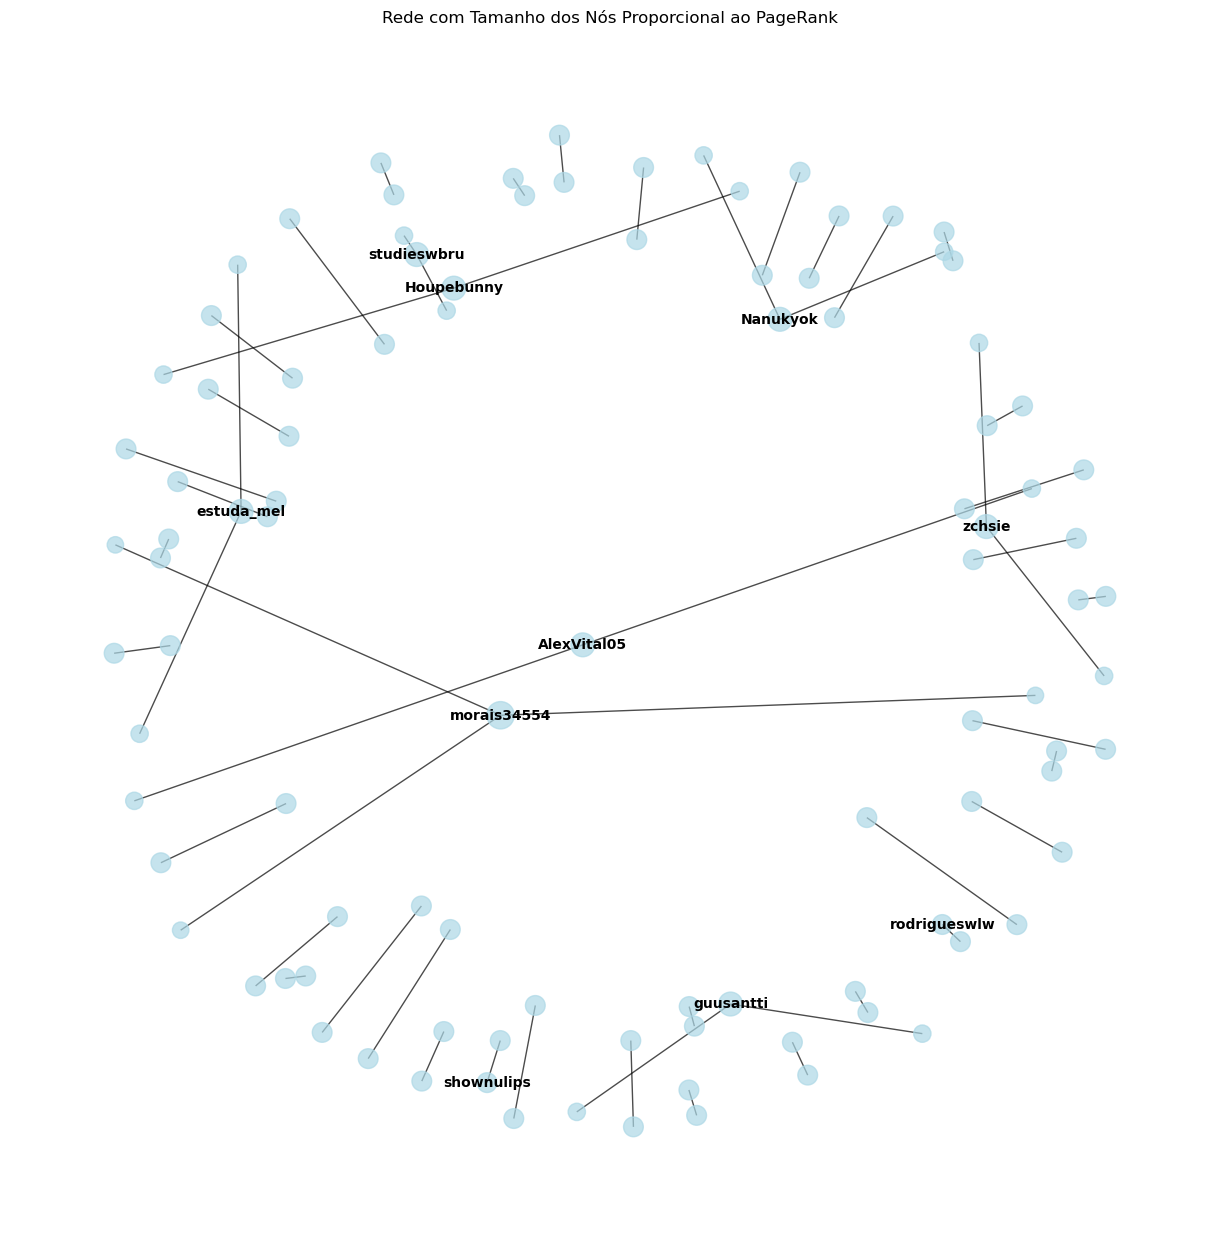

In [20]:
# Calcular diferentes métricas de centralidade
print("\n--- Análise de Centralidade ---")

# Calcular centralidade de grau
degree_centrality = nx.degree_centrality(G_undirected)

# Calcular centralidade de intermediação (betweenness)
betweenness_centrality = nx.betweenness_centrality(G_undirected)

# Calcular PageRank
pagerank = nx.pagerank(G_undirected)

# Criar DataFrame com as métricas
centrality_df = pd.DataFrame({
    'Node': list(G_undirected.nodes()),
    'Degree': [degree_centrality[n] for n in G_undirected.nodes()],
    'Betweenness': [betweenness_centrality[n] for n in G_undirected.nodes()],
    'PageRank': [pagerank[n] for n in G_undirected.nodes()]
})

# Ordenar por PageRank
centrality_df = centrality_df.sort_values('PageRank', ascending=False)

# Salvar métricas em CSV
centrality_df.to_csv("resultados_comunidades/node_centrality_metrics.csv", index=False)

# Mostrar os 10 nós mais centrais
print("Top 10 nós por PageRank:")
print(centrality_df.head(10)[['Node', 'PageRank', 'Degree', 'Betweenness']])

# Visualizar rede com tamanho dos nós proporcional ao PageRank
plt.figure(figsize=(12, 12))
nx.draw(G_undirected, pos_combined,
        node_size=[pagerank[n]*20000 for n in G_undirected.nodes()],
        node_color='lightblue',
        alpha=0.7,
        with_labels=False)

# Adicionar rótulos apenas para os nós mais importantes
top_nodes = centrality_df.head(10)['Node'].tolist()
labels = {node: node for node in top_nodes}
nx.draw_networkx_labels(G_undirected, pos_combined, labels=labels, font_size=10, font_weight='bold')

plt.title("Rede com Tamanho dos Nós Proporcional ao PageRank")
plt.savefig("resultados_comunidades/rede_pagerank.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [21]:
# Salvar os tweets coletados em CSV
df_tweets.to_csv("tweets_ENEM.csv", index=False)

# Salvar a rede em formato GraphML
nx.write_graphml(G_combined, "rede_ENEM_twitter.graphml")

print("\nDados e rede salvos com sucesso!")


Dados e rede salvos com sucesso!


Objetivo Geral do Código
Criar e analisar uma rede social construída com dados reais do Twitter, relacionados à ENEM (Universidade Federal do Tocantins), aplicando algoritmos de detecção de comunidades (Louvain, Label Propagation e Leiden), além de identificar usuários centrais por métricas como PageRank, grau e betweenness.

1. Coleta de Dados via Webcrawler (API do Twitter)
Objetivo: Coletar tweets que mencionem a ENEM com termos como “ENEM”, “@ENEM”, “Universidade Federal do Tocantins”, etc.

Método: Uso da biblioteca tweepy com a API v2 do Twitter.

Dados extraídos por tweet:

Autor do tweet.

Texto do tweet.

Métricas de engajamento (curtidas, retweets, respostas).

Menções a outros usuários.

Se é retweet, citação ou resposta a outro tweet.

Resultado: Criação de um DataFrame com as informações dos tweets coletados, contendo autores, texto, interações e menções.

2. Construção de Três Redes
As redes construídas representam como os usuários interagem em torno do tema ENEM:

a. Rede de Menções
Nós: Usuários do Twitter.

Arestas dirigidas: Um usuário mencionando outro.

Peso da aresta: Quantidade de vezes que um autor mencionou outro.

b. Rede de Interações
Baseada em: Respostas, retweets e citações.

Aresta dirigida de A → B: A interagiu com um tweet do B.

c. Rede Combinada
União das redes de menções e interações, somando pesos se houver sobreposição.

Utilizada para análise e detecção de comunidades.

Resultados básicos exibidos:

Número de nós (usuários únicos).

Número de arestas (interações ou menções).

Densidade da rede (nível de interconectividade).

3. Visualização das Redes
Layout visual: spring_layout (força de repulsão e atração entre nós).

Tamanho dos nós: Proporcional ao grau.

Rótulos: Apenas para os 10 nós com maior grau.

As figuras geradas mostram clusters de usuários e padrões de conectividade.

4. Detecção de Comunidades
A comunidade é um grupo de usuários mais fortemente conectados entre si do que com o resto da rede.

a. Algoritmo de Louvain
Maximiza a modularidade.

Resultado:

29 comunidades.

Modularidade: 0.7634 (alta).

Comunidade maior: 30 usuários.

Comunidade menor: 2 usuários.

b. Algoritmo de Label Propagation
Baseado na propagação de rótulos entre vizinhos.

Resultado:

38 comunidades (mais fragmentado).

Modularidade: 0.7093.

Tamanho médio menor.

c. Algoritmo de Leiden
Refinamento do Louvain com garantia de conexidade.

Resultado:

29 comunidades.

Modularidade: 0.7639 (ligeiramente superior ao Louvain).

A modularidade mede o quanto as comunidades são “bem definidas”. Quanto mais próxima de 1, melhor.

5. Comparação dos Algoritmos
Representada em gráficos:

Modularidade.

Número de comunidades.

Observação: Leiden tem a melhor modularidade, mas Louvain é quase equivalente. LPA é mais rápido, porém menos preciso.

6. Análise das Principais Comunidades
Para os 3 algoritmos:

Exibem-se as 3 maiores comunidades.

Para cada comunidade:

Tamanho.

Nós centrais (mais conectados).

Densidade.

Coeficiente de aglomeração (grau de formação de triângulos).

Ajuda a entender a coesão dos grupos formados.

7. Análise de Centralidade
Objetivo: descobrir os usuários mais influentes da rede.

Degree Centrality: Quem tem mais conexões.

Betweenness: Quem está no meio de mais caminhos (mediador).

PageRank: Importância com base nas conexões de quem te conecta.

Ex: ENEM_Cryptonite e ENEM aparecem como centrais, com maior PageRank e grau.

O que os elementos da rede representam
Elemento	Representa
Nó	Um usuário do Twitter
Aresta	Uma interação (menção, resposta, retweet) entre dois usuários
Comunidade	Grupo de usuários fortemente conectados entre si
Peso da Aresta	Número de vezes que um usuário interagiu com outro
Densidade	Grau de conectividade dentro da rede ou comunidade

